In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = "725-50"
obs_mode = "IPOL"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
# print("Interleaved Values")
# print("Length: ", len(interleaved_values))
# print(interleaved_values)
# print("Interleaved Stds")
# print("Length: ", len(interleaved_stds))
# print(interleaved_stds[0 : 10])
# print("Configuration List")
# print("Length: ", len(configuration_list))
# print(configuration_list)
# print(interleaved_stds[0])

# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [3]:
# Latest JSON starting fit is loaded in the next cell.


In [4]:
# Ideal start with HWP/IMR phi values from the broadband table
hwp_phi_waves = 0.465
imr_phi_waves = 0.446

theta_pol = 0

delta_HWP = 2 * np.pi * hwp_phi_waves
offset_HWP = 0

delta_derot = 2 * np.pi * imr_phi_waves

delta_opts = 0
epsilon_opts = 0
rot_opts = 0

delta_FLC = 2 * np.pi * 0.5
rot_FLC = 0

dichroic_phi = 0
dichroic_epsilon = 0
dichroic_theta = 0

em_gain = 1.0  # Fixed ideal EM gain

past_fit = {
    "dichroic": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
    "flc": {"phi": delta_FLC, "delta_theta": rot_FLC},
    "optics": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
    "image_rotator": {"phi": delta_derot},
    "hwp": {"phi": delta_HWP, "delta_theta": offset_HWP},
    "lp": {"theta": theta_pol},
}

print("Ideal table start for 725 nm")
print("HWP phi waves:", hwp_phi_waves)
print("IMR phi waves:", imr_phi_waves)
print("Past Fit: ", past_fit)

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

print(system_dict)


Ideal table start for 725 nm
HWP phi waves: 0.465
IMR phi waves: 0.446
Past Fit:  {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 2.8023006470020957}, 'hwp': {'phi': 2.921681167838508, 'delta_theta': 0}, 'lp': {'theta': 0}}
{'components': {'wollaston': {'type': 'wollaston_prism_function', 'properties': {'beam': 'o', 'transmission_ratio': 1.0}}, 'dichroic': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'flc': {'type': 'general_retarder_function', 'properties': {'phi': 3.141592653589793, 'theta': 0, 'delta_theta': 0}}, 'optics': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'image_rotator': {'type': 'general_retarder_function', 'properties': {'phi': 2.8023006470020957, 'theta': 0, 'delta_theta': 0}}, 'hwp': {'type': 'general_retarder_function', 'properties': {'ph

In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.5 0.5 0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 2.8023006470020957}, 'hwp': {'phi': 2.921681167838508, 'delta_theta': 0}, 'lp': {'theta': 0}}
logl value: 7306.094692739011


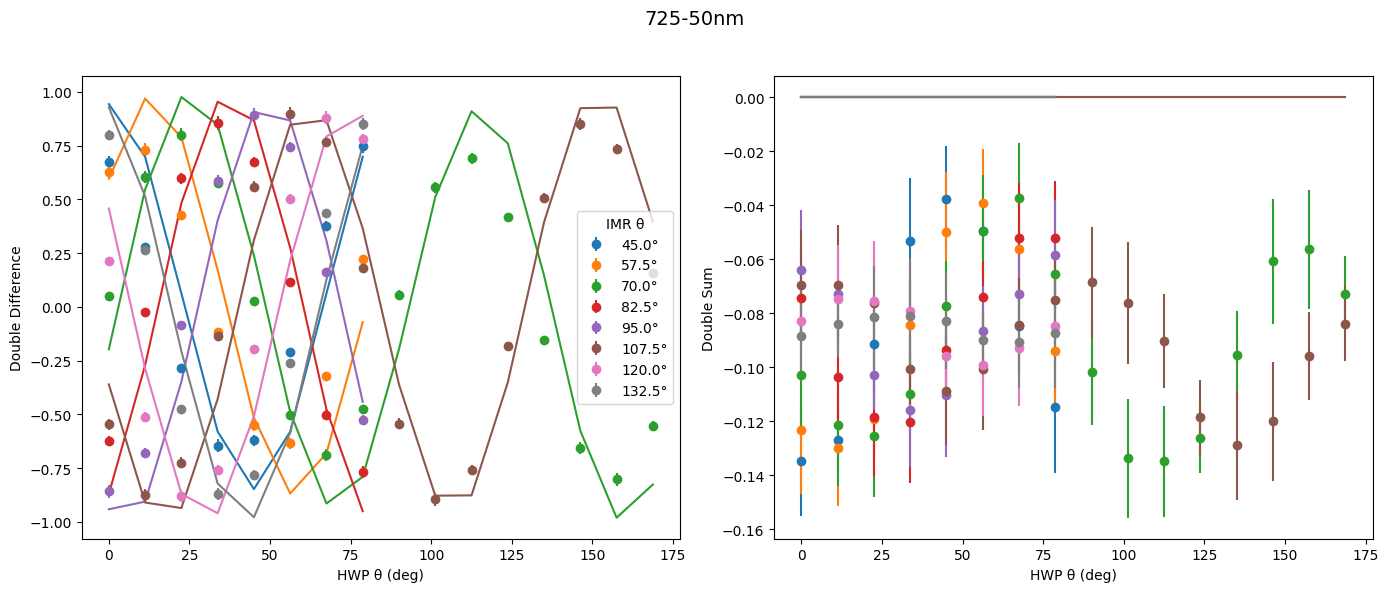

In [6]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)
p0.setdefault("image_rotator", {}).pop("delta_theta", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting initial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)


# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 2.8023006470020957}, 'hwp': {'phi': 2.921681167838508, 'delta_theta': 0}, 'lp': {'theta': 0}}
Iteration #: 1
logl_value: 960.2739406496702
Best Fit Parameters: [ 0.99563583  0.08308026 -3.6837723   3.35910482  0.11311901  2.90365018
  0.01049955  1.52270804  2.80447543  2.72815385  2.85196613 -1.90166109]


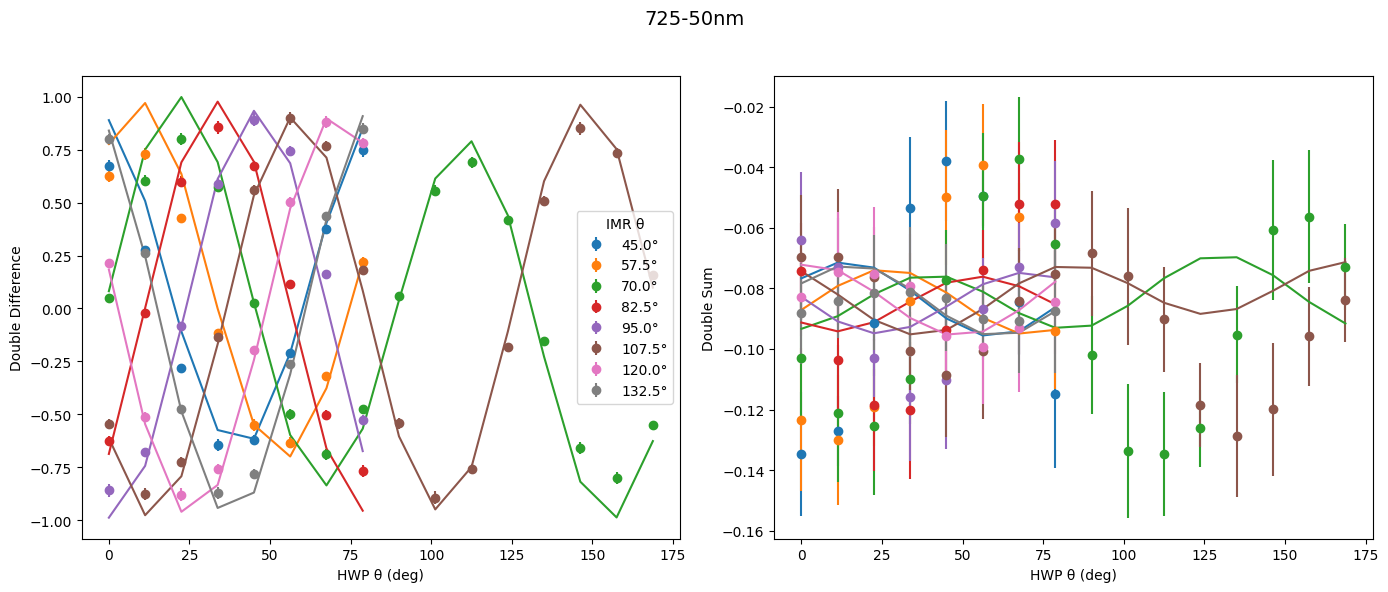

After p0: {'dichroic': {'phi': 0.9956358295064354, 'epsilon': 0.08308026303346513, 'theta': -3.683772302493912}, 'flc': {'phi': 3.359104818279355, 'delta_theta': 0.11311900969124455}, 'optics': {'phi': 2.903650175985427, 'epsilon': 0.010499549127387127, 'theta': 1.5227080384692449}, 'image_rotator': {'phi': 2.8044754296606715}, 'hwp': {'phi': 2.728153851662552, 'delta_theta': 2.851966132767702}, 'lp': {'theta': -1.9016610895358341}}
Before p0: {'dichroic': {'phi': 0.9956358295064354, 'epsilon': 0.08308026303346513, 'theta': -3.683772302493912}, 'flc': {'phi': 3.359104818279355, 'delta_theta': 0.11311900969124455}, 'optics': {'phi': 2.903650175985427, 'epsilon': 0.010499549127387127, 'theta': 1.5227080384692449}, 'image_rotator': {'phi': 2.8044754296606715}, 'hwp': {'phi': 2.728153851662552, 'delta_theta': 2.851966132767702}, 'lp': {'theta': -1.9016610895358341}}
Iteration #: 2
logl_value: 52.90244627597892
Best Fit Parameters: [ 2.03721648e+00  9.74557619e-02 -1.11279618e+01  3.6443489

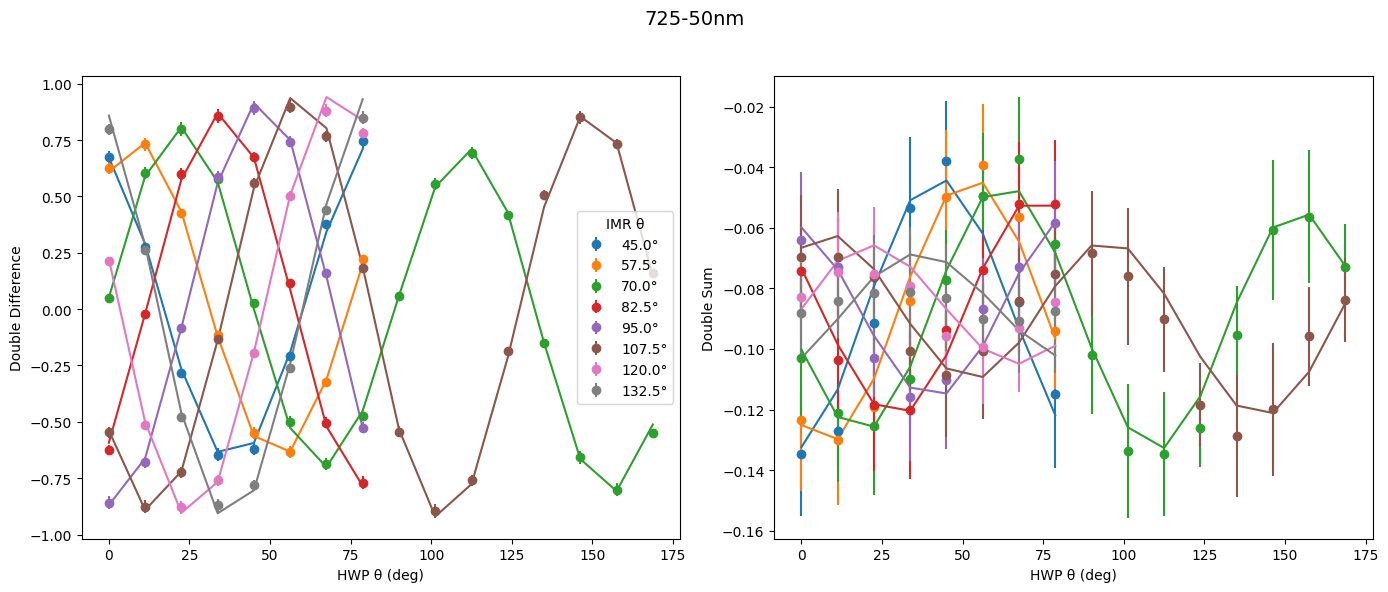

After p0: {'dichroic': {'phi': 2.0372164780971174, 'epsilon': 0.09745576190953578, 'theta': -11.127961828842288}, 'flc': {'phi': 3.6443489884918057, 'delta_theta': 0.28495152457130046}, 'optics': {'phi': 1.3111176518059353, 'epsilon': 0.009526737192485656, 'theta': 2.3742392955562117}, 'image_rotator': {'phi': 2.882319182370849}, 'hwp': {'phi': 3.0289778128957474, 'delta_theta': 3.352003337060667}, 'lp': {'theta': 4.994155771037237}}
Before p0: {'dichroic': {'phi': 2.0372164780971174, 'epsilon': 0.09745576190953578, 'theta': -11.127961828842288}, 'flc': {'phi': 3.6443489884918057, 'delta_theta': 0.28495152457130046}, 'optics': {'phi': 1.3111176518059353, 'epsilon': 0.009526737192485656, 'theta': 2.3742392955562117}, 'image_rotator': {'phi': 2.882319182370849}, 'hwp': {'phi': 3.0289778128957474, 'delta_theta': 3.352003337060667}, 'lp': {'theta': 4.994155771037237}}
Iteration #: 3
logl_value: 48.93037799952563
Best Fit Parameters: [ 1.18688701e+00  9.32768985e-02 -6.33174103e+00  3.56373

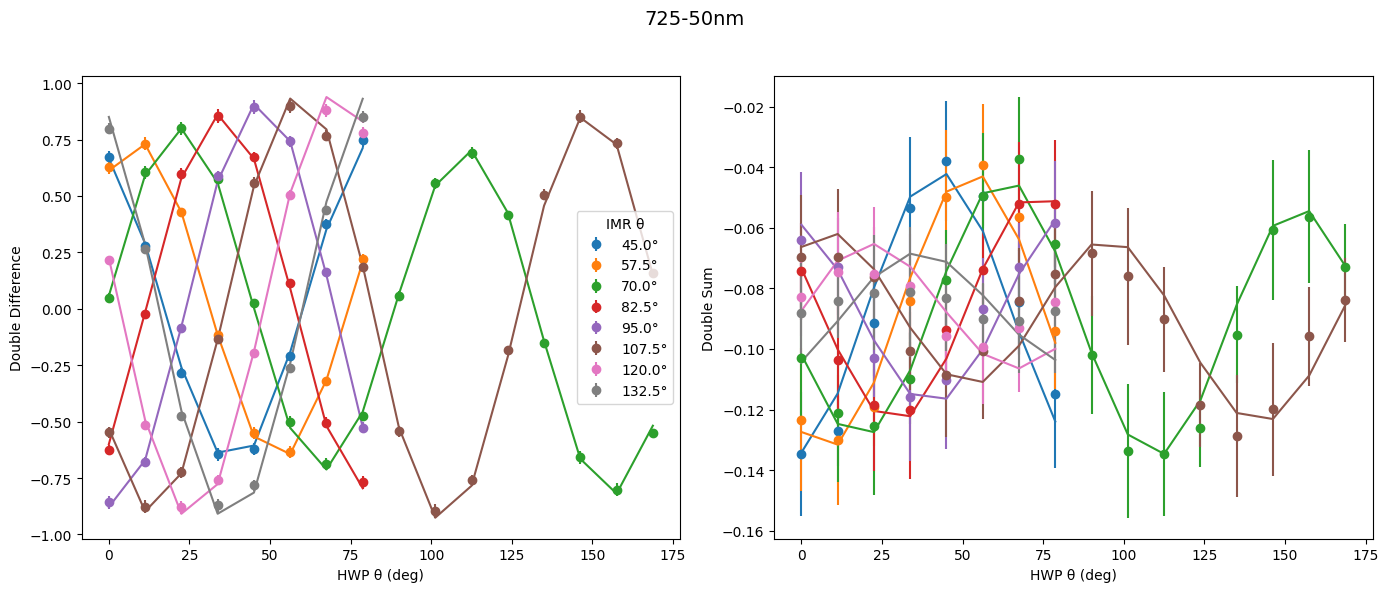

After p0: {'dichroic': {'phi': 1.1868870147342534, 'epsilon': 0.0932768984769547, 'theta': -6.3317410277324635}, 'flc': {'phi': 3.5637368960076374, 'delta_theta': 3.118322236227163}, 'optics': {'phi': 0.7523080597822012, 'epsilon': 0.0057583298120530285, 'theta': -18.13721284950355}, 'image_rotator': {'phi': 2.884231243574347}, 'hwp': {'phi': 3.0289460817061844, 'delta_theta': 3.1982314660869786}, 'lp': {'theta': 4.909542338593458}}
Before p0: {'dichroic': {'phi': 1.1868870147342534, 'epsilon': 0.0932768984769547, 'theta': -6.3317410277324635}, 'flc': {'phi': 3.5637368960076374, 'delta_theta': 3.118322236227163}, 'optics': {'phi': 0.7523080597822012, 'epsilon': 0.0057583298120530285, 'theta': -18.13721284950355}, 'image_rotator': {'phi': 2.884231243574347}, 'hwp': {'phi': 3.0289460817061844, 'delta_theta': 3.1982314660869786}, 'lp': {'theta': 4.909542338593458}}
Iteration #: 4
logl_value: 48.677940539689175
Best Fit Parameters: [ 1.33567162e+00  9.26460806e-02 -5.29603600e+00  3.533713

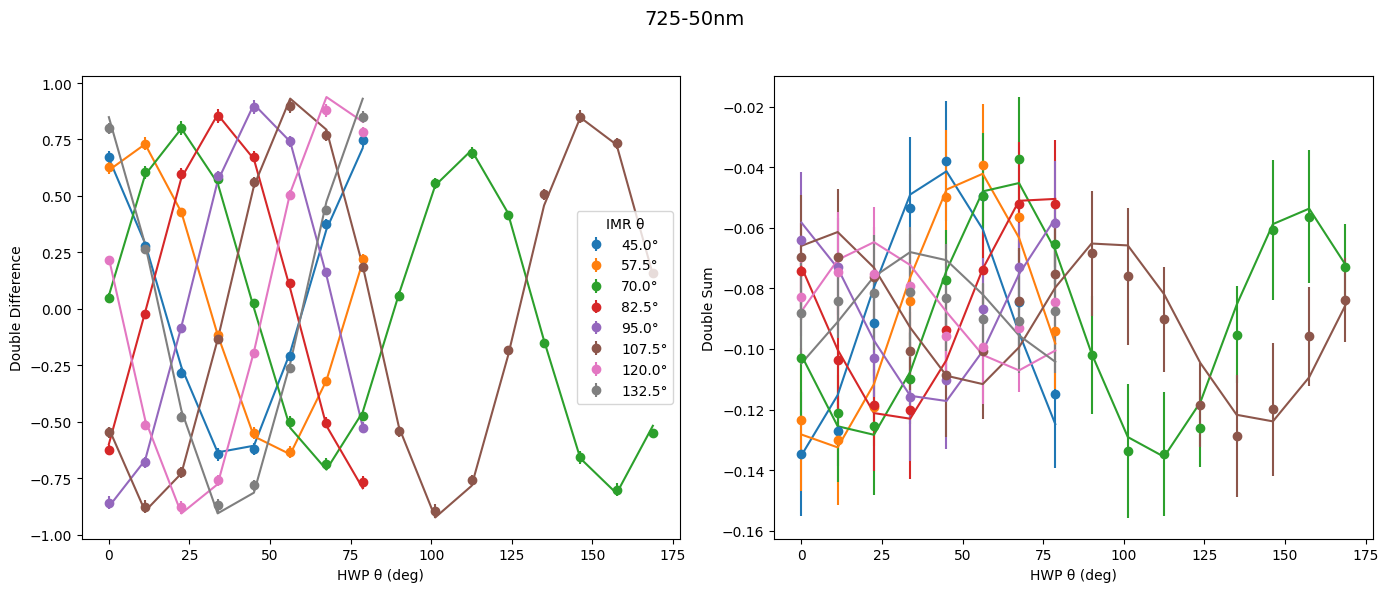

After p0: {'dichroic': {'phi': 1.3356716225188685, 'epsilon': 0.09264608063181251, 'theta': -5.296035997985623}, 'flc': {'phi': 3.533713589299545, 'delta_theta': 2.8230995638876806}, 'optics': {'phi': 0.6948500168979574, 'epsilon': 0.0067786945217476816, 'theta': -22.364820924619977}, 'image_rotator': {'phi': 2.886018838133646}, 'hwp': {'phi': 3.0303869501300174, 'delta_theta': 3.1548537730910944}, 'lp': {'theta': 4.762973444710942}}
Before p0: {'dichroic': {'phi': 1.3356716225188685, 'epsilon': 0.09264608063181251, 'theta': -5.296035997985623}, 'flc': {'phi': 3.533713589299545, 'delta_theta': 2.8230995638876806}, 'optics': {'phi': 0.6948500168979574, 'epsilon': 0.0067786945217476816, 'theta': -22.364820924619977}, 'image_rotator': {'phi': 2.886018838133646}, 'hwp': {'phi': 3.0303869501300174, 'delta_theta': 3.1548537730910944}, 'lp': {'theta': 4.762973444710942}}
Iteration #: 5
logl_value: 48.421871605675896
Best Fit Parameters: [ 1.33164345e+00  9.21211025e-02 -4.30939657e+00  3.4881

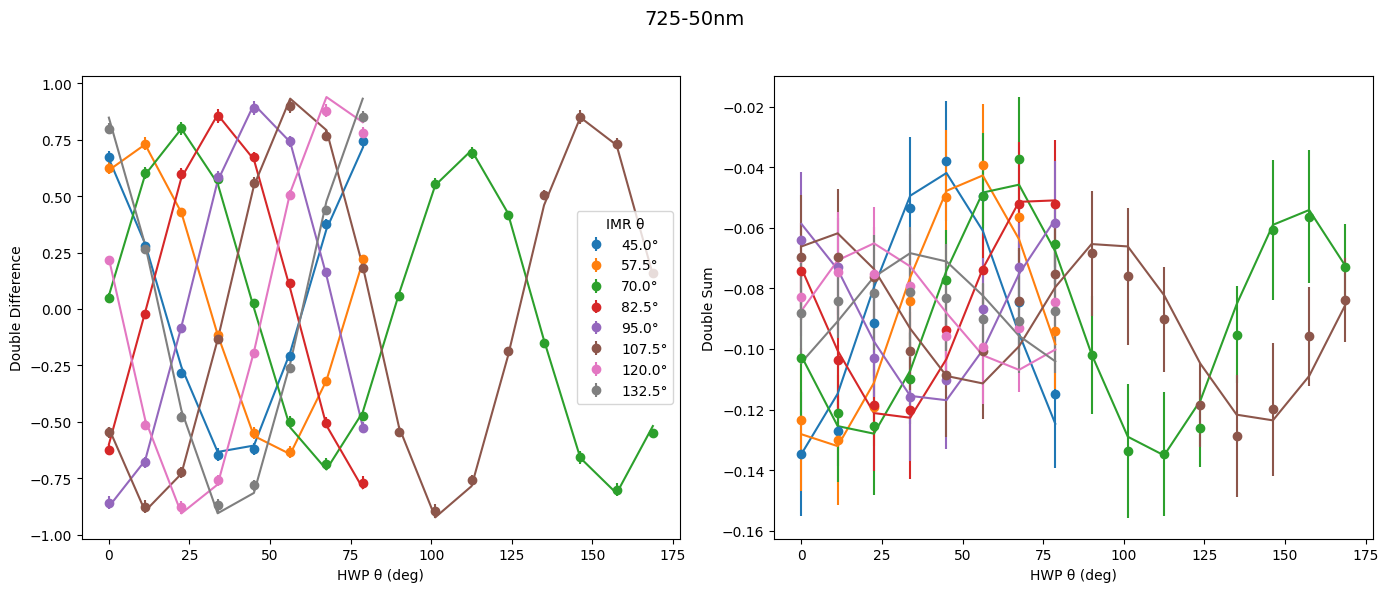

After p0: {'dichroic': {'phi': 1.3316434468644331, 'epsilon': 0.0921211024791039, 'theta': -4.309396569406026}, 'flc': {'phi': 3.4881665272879996, 'delta_theta': 3.001804987820588}, 'optics': {'phi': 0.6474707142447804, 'epsilon': 0.006825038049081446, 'theta': -26.739666937245516}, 'image_rotator': {'phi': 2.8849192362646487}, 'hwp': {'phi': 3.030444903229778, 'delta_theta': 3.304393400778589}, 'lp': {'theta': 4.9929717212021885}}
Before p0: {'dichroic': {'phi': 1.3316434468644331, 'epsilon': 0.0921211024791039, 'theta': -4.309396569406026}, 'flc': {'phi': 3.4881665272879996, 'delta_theta': 3.001804987820588}, 'optics': {'phi': 0.6474707142447804, 'epsilon': 0.006825038049081446, 'theta': -26.739666937245516}, 'image_rotator': {'phi': 2.8849192362646487}, 'hwp': {'phi': 3.030444903229778, 'delta_theta': 3.304393400778589}, 'lp': {'theta': 4.9929717212021885}}
Iteration #: 6
logl_value: 48.41196353868321
Best Fit Parameters: [ 1.06881361e+00  9.22726309e-02 -4.58197077e+00  3.48253688e

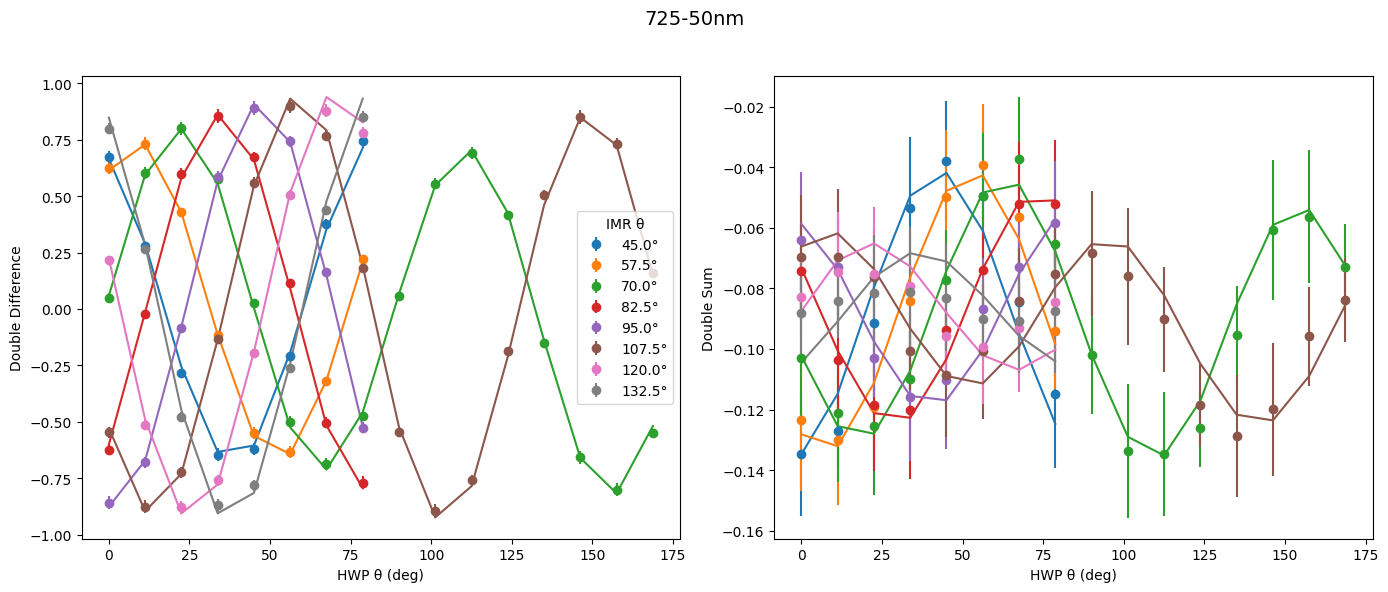

After p0: {'dichroic': {'phi': 1.0688136142033544, 'epsilon': 0.09227263092096111, 'theta': -4.581970774028402}, 'flc': {'phi': 3.4825368811621598, 'delta_theta': 3.42358801980928}, 'optics': {'phi': 0.6458522549270302, 'epsilon': 0.00676572689606246, 'theta': -27.287355153996515}, 'image_rotator': {'phi': 2.8848235336407484}, 'hwp': {'phi': 3.0304346714226362, 'delta_theta': 3.3187239391559054}, 'lp': {'theta': 4.998592229117321}}
Before p0: {'dichroic': {'phi': 1.0688136142033544, 'epsilon': 0.09227263092096111, 'theta': -4.581970774028402}, 'flc': {'phi': 3.4825368811621598, 'delta_theta': 3.42358801980928}, 'optics': {'phi': 0.6458522549270302, 'epsilon': 0.00676572689606246, 'theta': -27.287355153996515}, 'image_rotator': {'phi': 2.8848235336407484}, 'hwp': {'phi': 3.0304346714226362, 'delta_theta': 3.3187239391559054}, 'lp': {'theta': 4.998592229117321}}
Iteration #: 7
logl_value: 48.40034523462663
Best Fit Parameters: [ 8.27193507e-01  9.27118571e-02 -5.36987233e+00  3.48129940e

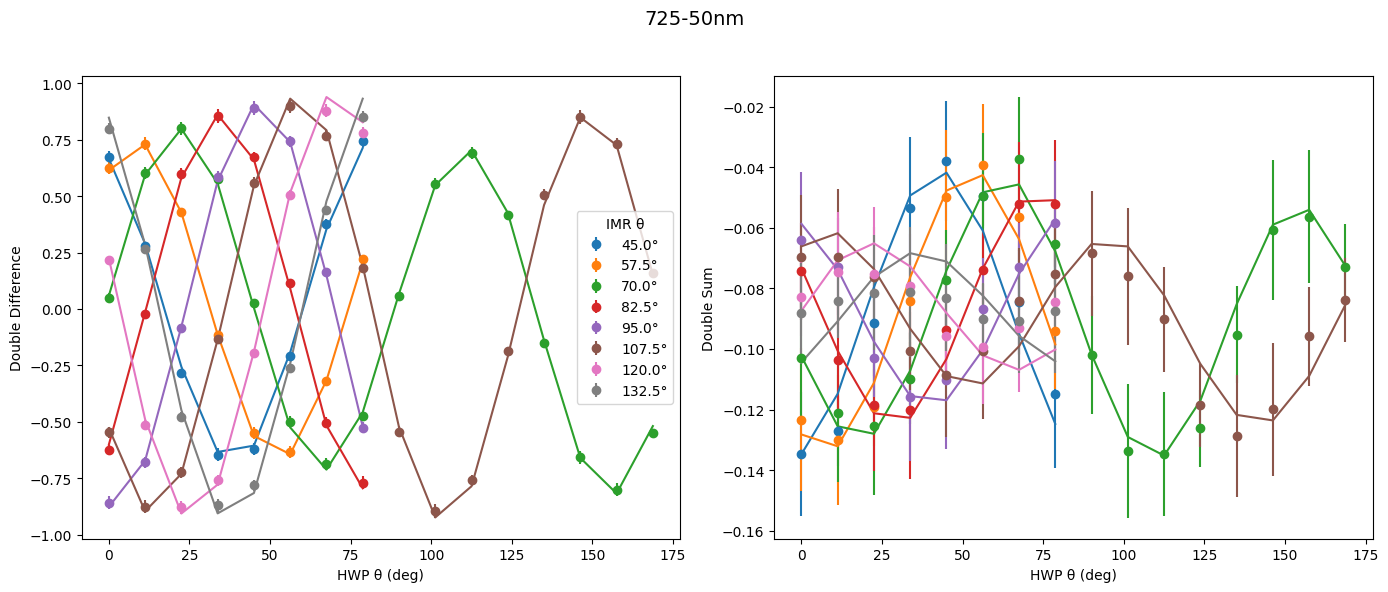

After p0: {'dichroic': {'phi': 0.8271935068459457, 'epsilon': 0.09271185706656002, 'theta': -5.369872327117166}, 'flc': {'phi': 3.4812994036916933, 'delta_theta': 3.7446464254946417}, 'optics': {'phi': 0.6468266004463432, 'epsilon': 0.00645311314235756, 'theta': -27.37023134350069}, 'image_rotator': {'phi': 2.8847356436280824}, 'hwp': {'phi': 3.0304975563499648, 'delta_theta': 3.3139710675337435}, 'lp': {'theta': 4.999772826722962}}
Before p0: {'dichroic': {'phi': 0.8271935068459457, 'epsilon': 0.09271185706656002, 'theta': -5.369872327117166}, 'flc': {'phi': 3.4812994036916933, 'delta_theta': 3.7446464254946417}, 'optics': {'phi': 0.6468266004463432, 'epsilon': 0.00645311314235756, 'theta': -27.37023134350069}, 'image_rotator': {'phi': 2.8847356436280824}, 'hwp': {'phi': 3.0304975563499648, 'delta_theta': 3.3139710675337435}, 'lp': {'theta': 4.999772826722962}}
Iteration #: 8
logl_value: 48.39593015278416
Best Fit Parameters: [ 6.89132486e-01  9.31335575e-02 -6.01626949e+00  3.4755891

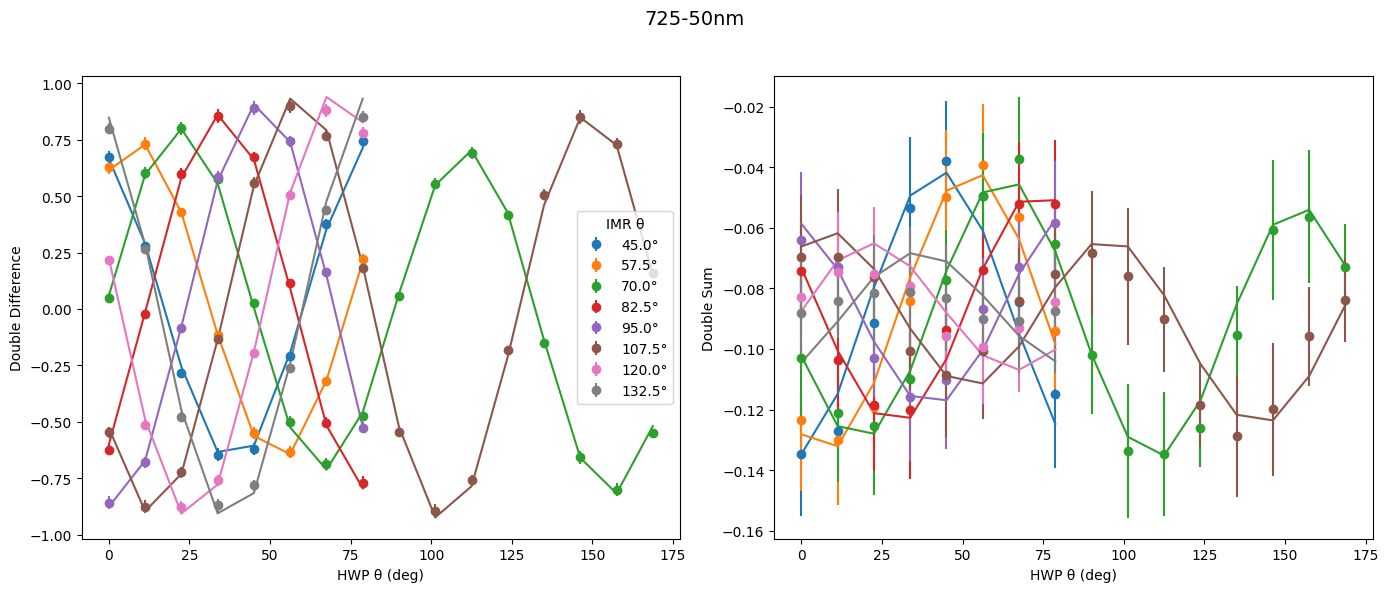

After p0: {'dichroic': {'phi': 0.6891324861696266, 'epsilon': 0.09313355747712665, 'theta': -6.016269485579915}, 'flc': {'phi': 3.475589106664067, 'delta_theta': 3.9085631543162034}, 'optics': {'phi': 0.6430832133960243, 'epsilon': 0.006461721327176501, 'theta': -27.905692552189223}, 'image_rotator': {'phi': 2.8849109910758663}, 'hwp': {'phi': 3.030537727945596, 'delta_theta': 3.302828499043784}, 'lp': {'theta': 4.98633204643005}}
Before p0: {'dichroic': {'phi': 0.6891324861696266, 'epsilon': 0.09313355747712665, 'theta': -6.016269485579915}, 'flc': {'phi': 3.475589106664067, 'delta_theta': 3.9085631543162034}, 'optics': {'phi': 0.6430832133960243, 'epsilon': 0.006461721327176501, 'theta': -27.905692552189223}, 'image_rotator': {'phi': 2.8849109910758663}, 'hwp': {'phi': 3.030537727945596, 'delta_theta': 3.302828499043784}, 'lp': {'theta': 4.98633204643005}}
Iteration #: 9
logl_value: 48.3834956539572
Best Fit Parameters: [ 5.33085545e-01  9.40423867e-02 -7.21015791e+00  3.46787298e+00

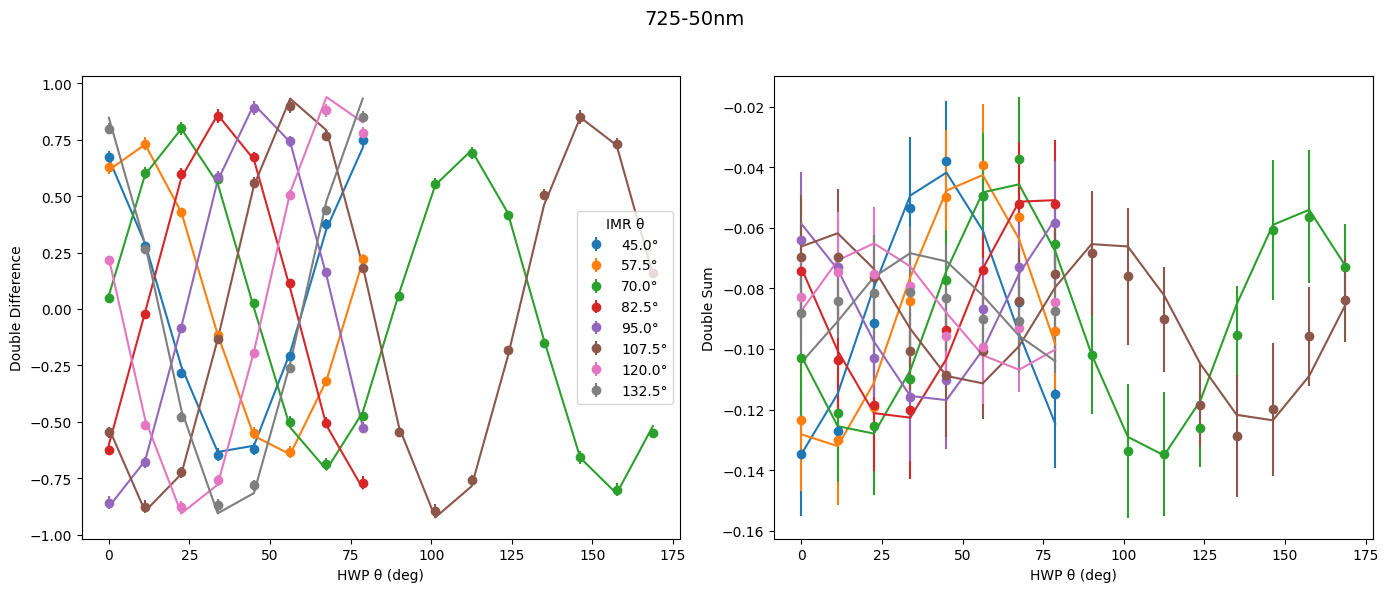

After p0: {'dichroic': {'phi': 0.5330855446182923, 'epsilon': 0.09404238673385304, 'theta': -7.210157911467235}, 'flc': {'phi': 3.4678729820317233, 'delta_theta': 4.065763841600784}, 'optics': {'phi': 0.6375640743521398, 'epsilon': 0.006051529216790098, 'theta': -28.5935169734488}, 'image_rotator': {'phi': 2.8849696854675884}, 'hwp': {'phi': 3.030349002180186, 'delta_theta': 3.296061184281653}, 'lp': {'theta': 4.972464255380322}}
Before p0: {'dichroic': {'phi': 0.5330855446182923, 'epsilon': 0.09404238673385304, 'theta': -7.210157911467235}, 'flc': {'phi': 3.4678729820317233, 'delta_theta': 4.065763841600784}, 'optics': {'phi': 0.6375640743521398, 'epsilon': 0.006051529216790098, 'theta': -28.5935169734488}, 'image_rotator': {'phi': 2.8849696854675884}, 'hwp': {'phi': 3.030349002180186, 'delta_theta': 3.296061184281653}, 'lp': {'theta': 4.972464255380322}}
Iteration #: 10
logl_value: 48.30347422221892
Best Fit Parameters: [ 3.57833344e-01  9.82127787e-02 -1.09580878e+01  3.47543771e+00

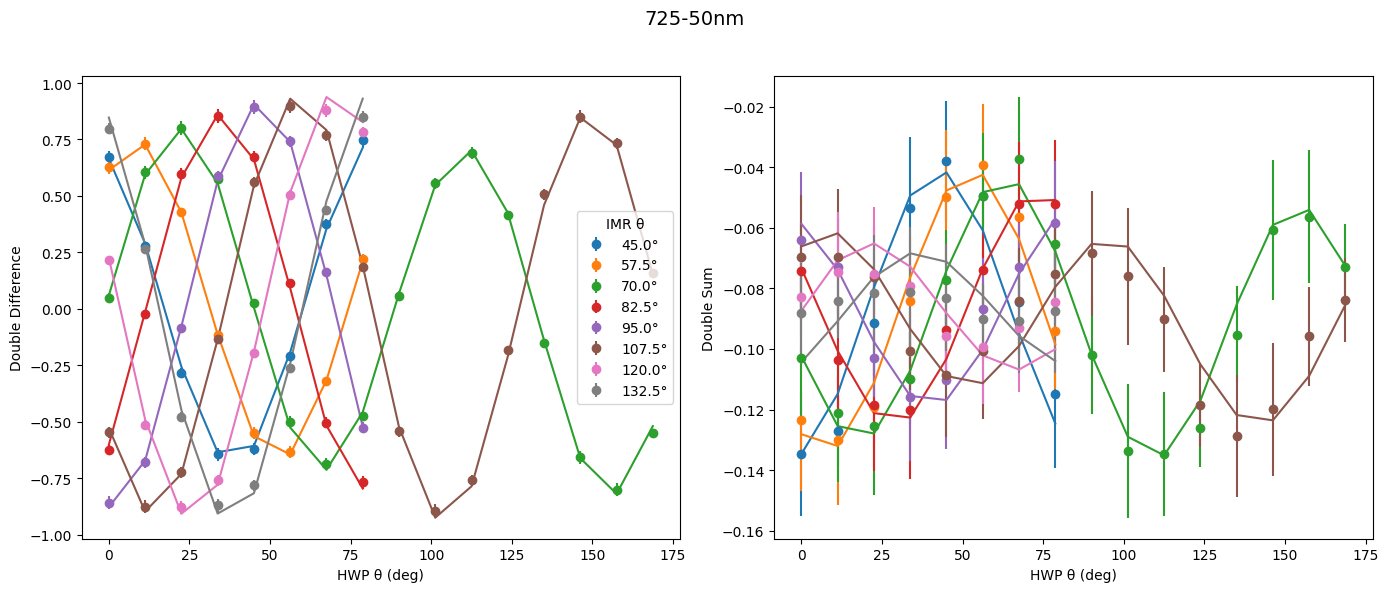

After p0: {'dichroic': {'phi': 0.35783334441247505, 'epsilon': 0.09821277874385304, 'theta': -10.958087847635916}, 'flc': {'phi': 3.4754377147460556, 'delta_theta': 4.298398620475663}, 'optics': {'phi': 0.6437716838766163, 'epsilon': 0.005523037953837486, 'theta': -27.76809610716988}, 'image_rotator': {'phi': 2.88457964653401}, 'hwp': {'phi': 3.029889483319657, 'delta_theta': 3.252204800331925}, 'lp': {'theta': 4.990761910559591}}
Before p0: {'dichroic': {'phi': 0.35783334441247505, 'epsilon': 0.09821277874385304, 'theta': -10.958087847635916}, 'flc': {'phi': 3.4754377147460556, 'delta_theta': 4.298398620475663}, 'optics': {'phi': 0.6437716838766163, 'epsilon': 0.005523037953837486, 'theta': -27.76809610716988}, 'image_rotator': {'phi': 2.88457964653401}, 'hwp': {'phi': 3.029889483319657, 'delta_theta': 3.252204800331925}, 'lp': {'theta': 4.990761910559591}}
Iteration #: 11
logl_value: 45.695308511560796
Best Fit Parameters: [ 6.78955280e-02  1.83331474e-01 -3.01134853e+01  3.36394757e

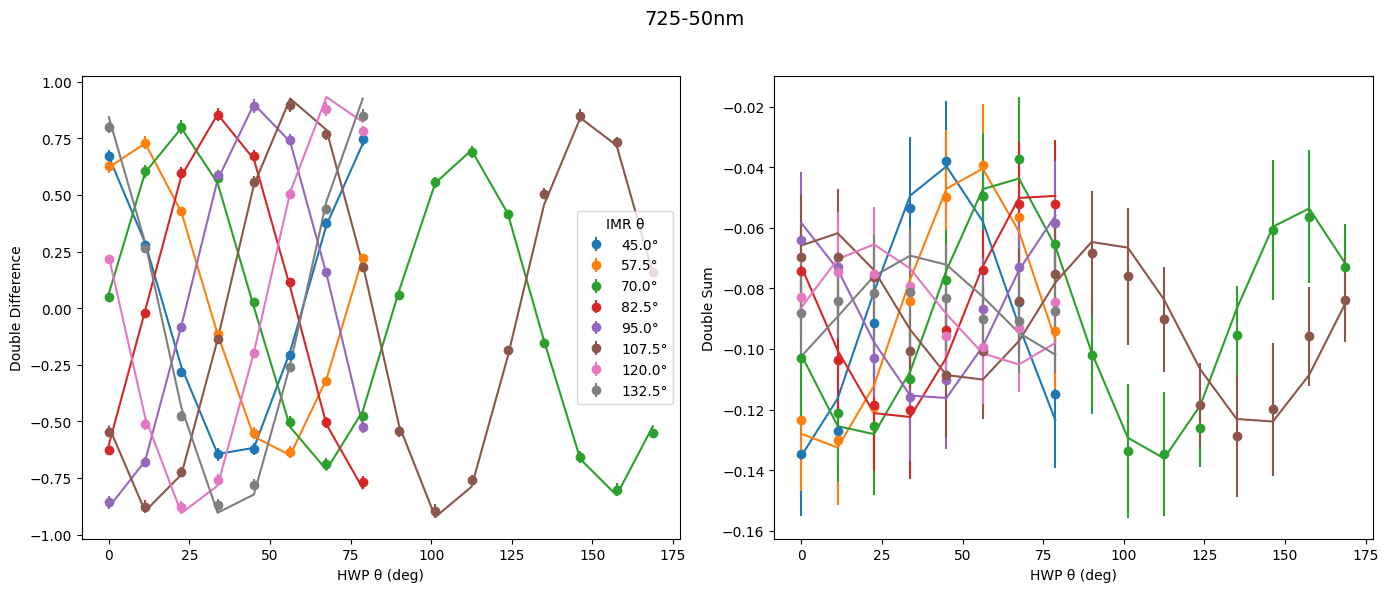

After p0: {'dichroic': {'phi': 0.0678955280232178, 'epsilon': 0.1833314735282266, 'theta': -30.113485302028664}, 'flc': {'phi': 3.363947566907002, 'delta_theta': 5.0}, 'optics': {'phi': 0.5431529122519327, 'epsilon': 0.001911838724972509, 'theta': -35.57264817890278}, 'image_rotator': {'phi': 2.8747421825405706}, 'hwp': {'phi': 3.0214436821104362, 'delta_theta': 1.8759830685714975}, 'lp': {'theta': 4.031322155431484}}
Before p0: {'dichroic': {'phi': 0.0678955280232178, 'epsilon': 0.1833314735282266, 'theta': -30.113485302028664}, 'flc': {'phi': 3.363947566907002, 'delta_theta': 5.0}, 'optics': {'phi': 0.5431529122519327, 'epsilon': 0.001911838724972509, 'theta': -35.57264817890278}, 'image_rotator': {'phi': 2.8747421825405706}, 'hwp': {'phi': 3.0214436821104362, 'delta_theta': 1.8759830685714975}, 'lp': {'theta': 4.031322155431484}}
Iteration #: 12
logl_value: 20.481010595902234
Best Fit Parameters: [-3.28380993e-02  3.74439218e-01 -3.78515461e+01  3.22725905e+00
  4.93705391e+00  3.51

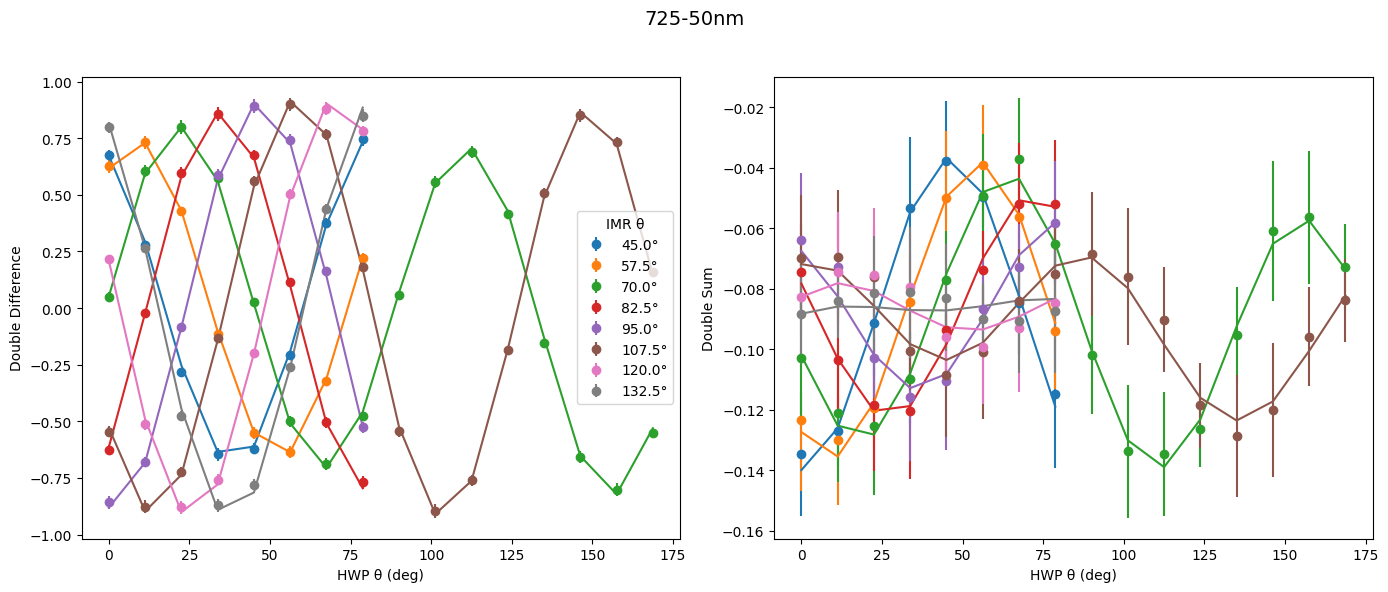

After p0: {'dichroic': {'phi': -0.03283809933135515, 'epsilon': 0.3744392175964575, 'theta': -37.85154606814703}, 'flc': {'phi': 3.227259046953737, 'delta_theta': 4.937053907061767}, 'optics': {'phi': 0.35168912544169295, 'epsilon': 0.0028867152730184358, 'theta': -48.37126085969416}, 'image_rotator': {'phi': 2.7617536589626983}, 'hwp': {'phi': 2.998447734616212, 'delta_theta': 1.9402105829261656}, 'lp': {'theta': 4.999965004781494}}
Before p0: {'dichroic': {'phi': -0.03283809933135515, 'epsilon': 0.3744392175964575, 'theta': -37.85154606814703}, 'flc': {'phi': 3.227259046953737, 'delta_theta': 4.937053907061767}, 'optics': {'phi': 0.35168912544169295, 'epsilon': 0.0028867152730184358, 'theta': -48.37126085969416}, 'image_rotator': {'phi': 2.7617536589626983}, 'hwp': {'phi': 2.998447734616212, 'delta_theta': 1.9402105829261656}, 'lp': {'theta': 4.999965004781494}}
Iteration #: 13
logl_value: 20.33807845469783
Best Fit Parameters: [-3.14848087e-02  3.75208550e-01 -3.78670851e+01  3.2292

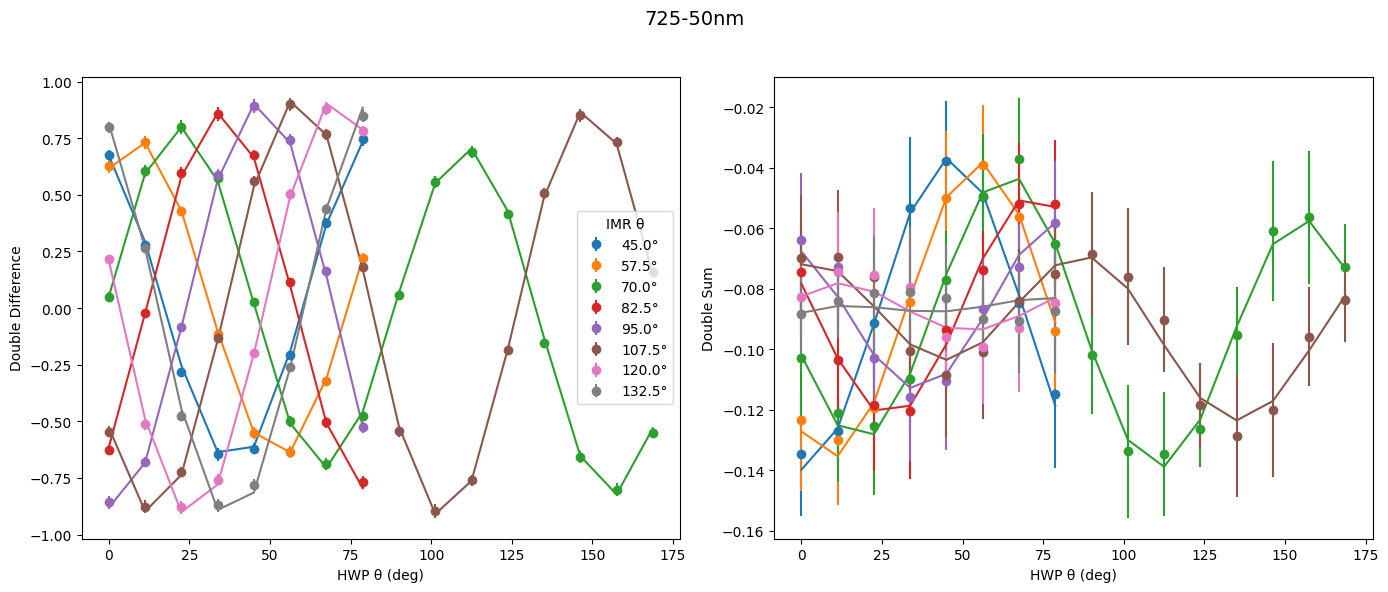

After p0: {'dichroic': {'phi': -0.03148480872454871, 'epsilon': 0.37520854965715417, 'theta': -37.86708507915434}, 'flc': {'phi': 3.2292078232041668, 'delta_theta': 4.999999975786517}, 'optics': {'phi': 0.35008021463157935, 'epsilon': 0.0028603509953866835, 'theta': -48.403057173527934}, 'image_rotator': {'phi': 2.7596815009255806}, 'hwp': {'phi': 2.998056263163613, 'delta_theta': 1.873083019100958}, 'lp': {'theta': 4.999983808417102}}
Before p0: {'dichroic': {'phi': -0.03148480872454871, 'epsilon': 0.37520854965715417, 'theta': -37.86708507915434}, 'flc': {'phi': 3.2292078232041668, 'delta_theta': 4.999999975786517}, 'optics': {'phi': 0.35008021463157935, 'epsilon': 0.0028603509953866835, 'theta': -48.403057173527934}, 'image_rotator': {'phi': 2.7596815009255806}, 'hwp': {'phi': 2.998056263163613, 'delta_theta': 1.873083019100958}, 'lp': {'theta': 4.999983808417102}}
Iteration #: 14
logl_value: 20.338077036803206
Best Fit Parameters: [-3.14744674e-02  3.75211349e-01 -3.78670119e+01  3

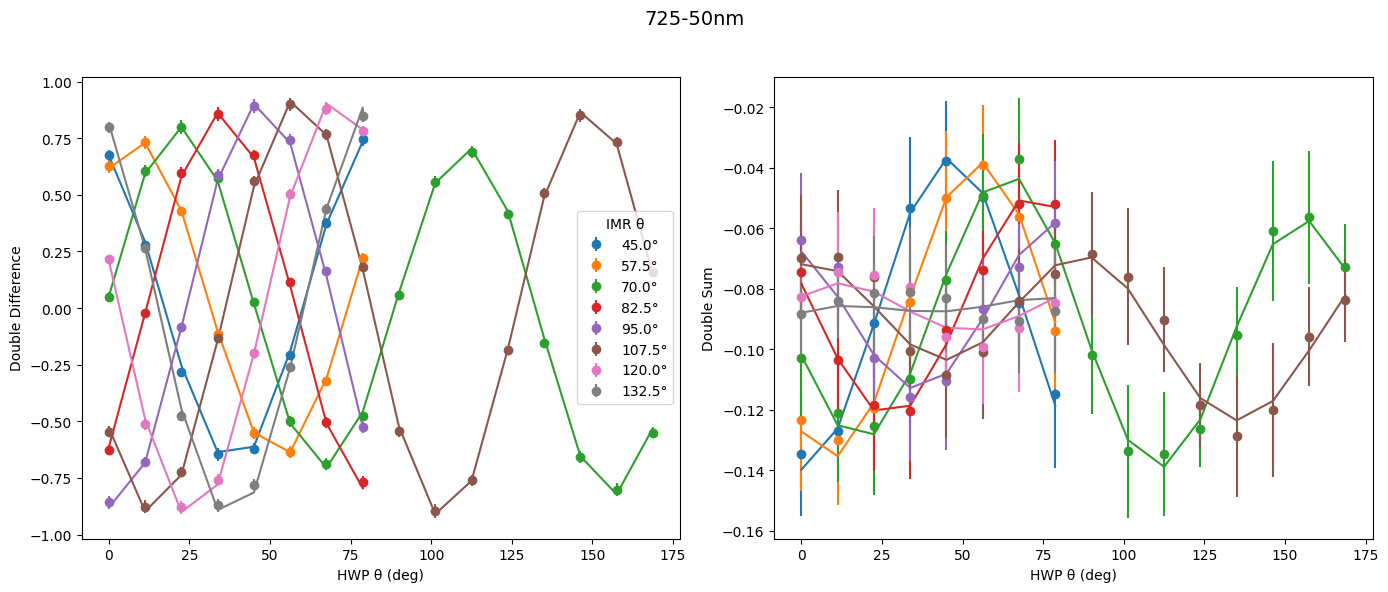

After p0: {'dichroic': {'phi': -0.03147446744207617, 'epsilon': 0.375211348826731, 'theta': -37.867011879996404}, 'flc': {'phi': 3.2292174087459355, 'delta_theta': 4.999999996240966}, 'optics': {'phi': 0.35007057196169344, 'epsilon': 0.0028614146014304762, 'theta': -48.401395723622684}, 'image_rotator': {'phi': 2.7596793097391092}, 'hwp': {'phi': 2.998061532833426, 'delta_theta': 1.8731079622505753}, 'lp': {'theta': 4.999985271872857}}
Before p0: {'dichroic': {'phi': -0.03147446744207617, 'epsilon': 0.375211348826731, 'theta': -37.867011879996404}, 'flc': {'phi': 3.2292174087459355, 'delta_theta': 4.999999996240966}, 'optics': {'phi': 0.35007057196169344, 'epsilon': 0.0028614146014304762, 'theta': -48.401395723622684}, 'image_rotator': {'phi': 2.7596793097391092}, 'hwp': {'phi': 2.998061532833426, 'delta_theta': 1.8731079622505753}, 'lp': {'theta': 4.999985271872857}}
Iteration #: 15
logl_value: 20.338076866966762
Best Fit Parameters: [-3.14772741e-02  3.75213492e-01 -3.78670583e+01  3

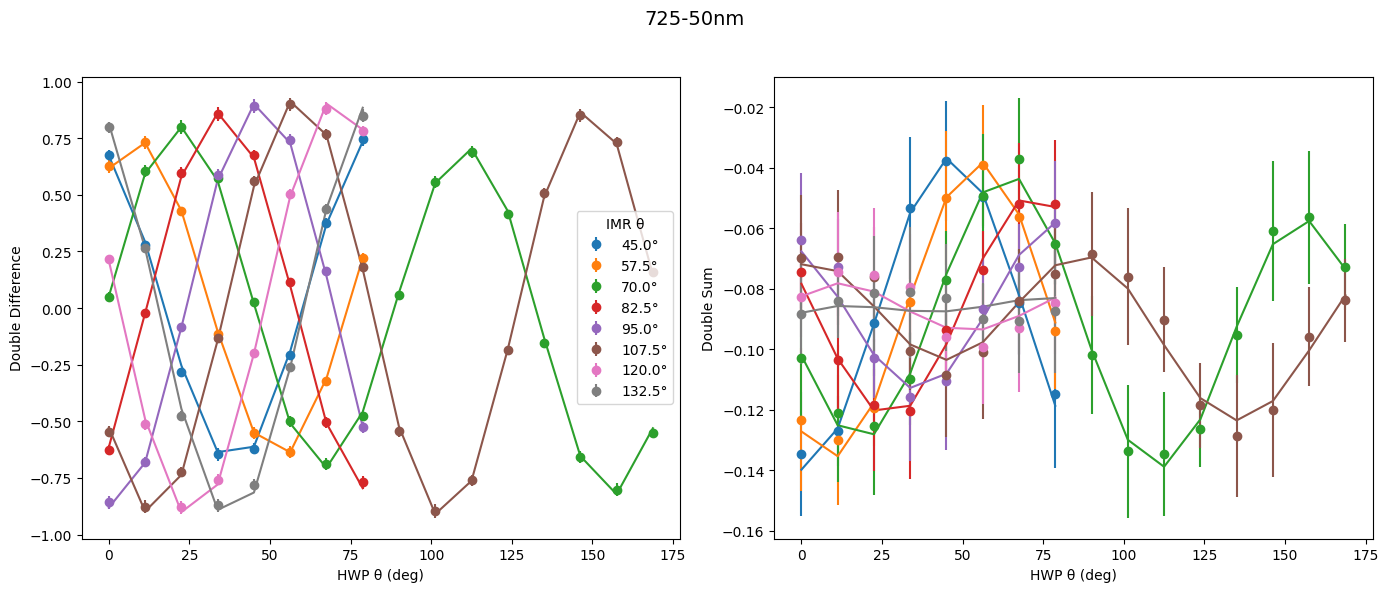

After p0: {'dichroic': {'phi': -0.03147727406539985, 'epsilon': 0.375213491513568, 'theta': -37.86705827286618}, 'flc': {'phi': 3.2292126240531394, 'delta_theta': 4.999999996267279}, 'optics': {'phi': 0.35006627563328474, 'epsilon': 0.0028629573492178415, 'theta': -48.400955317825876}, 'image_rotator': {'phi': 2.7596818068757143}, 'hwp': {'phi': 2.998059639178214, 'delta_theta': 1.8731061995427267}, 'lp': {'theta': 4.999984365928247}}
Before p0: {'dichroic': {'phi': -0.03147727406539985, 'epsilon': 0.375213491513568, 'theta': -37.86705827286618}, 'flc': {'phi': 3.2292126240531394, 'delta_theta': 4.999999996267279}, 'optics': {'phi': 0.35006627563328474, 'epsilon': 0.0028629573492178415, 'theta': -48.400955317825876}, 'image_rotator': {'phi': 2.7596818068757143}, 'hwp': {'phi': 2.998059639178214, 'delta_theta': 1.8731061995427267}, 'lp': {'theta': 4.999984365928247}}
Iteration #: 16
logl_value: 20.33807626055849
Best Fit Parameters: [-3.14704911e-02  3.75215742e-01 -3.78671093e+01  3.22

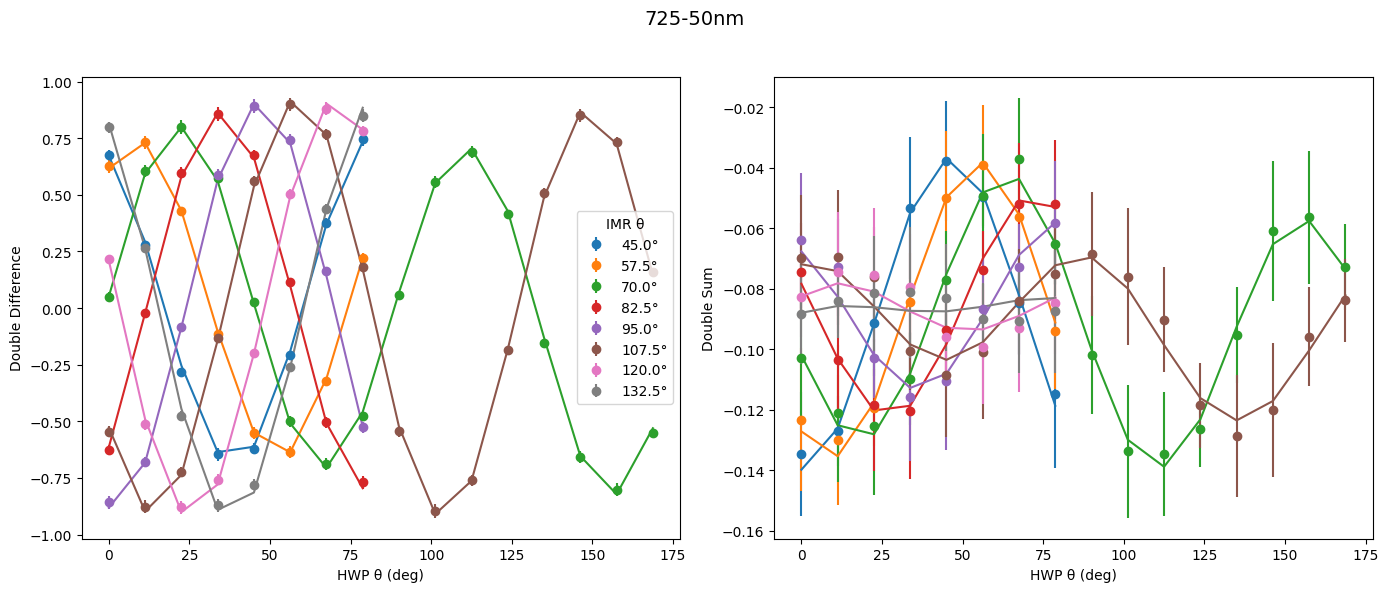

After p0: {'dichroic': {'phi': -0.03147049112243342, 'epsilon': 0.37521574234066774, 'theta': -37.867109291916584}, 'flc': {'phi': 3.2292244288558605, 'delta_theta': 4.999999992120311}, 'optics': {'phi': 0.3500684141305036, 'epsilon': 0.0028628212008062425, 'theta': -48.40093510420674}, 'image_rotator': {'phi': 2.759680585509037}, 'hwp': {'phi': 2.998058846180136, 'delta_theta': 1.8731008812485963}, 'lp': {'theta': 4.999998924926706}}
Before p0: {'dichroic': {'phi': -0.03147049112243342, 'epsilon': 0.37521574234066774, 'theta': -37.867109291916584}, 'flc': {'phi': 3.2292244288558605, 'delta_theta': 4.999999992120311}, 'optics': {'phi': 0.3500684141305036, 'epsilon': 0.0028628212008062425, 'theta': -48.40093510420674}, 'image_rotator': {'phi': 2.759680585509037}, 'hwp': {'phi': 2.998058846180136, 'delta_theta': 1.8731008812485963}, 'lp': {'theta': 4.999998924926706}}
Iteration #: 17
logl_value: 20.33807615729984
Best Fit Parameters: [-3.14849176e-02  3.75214590e-01 -3.78670859e+01  3.22

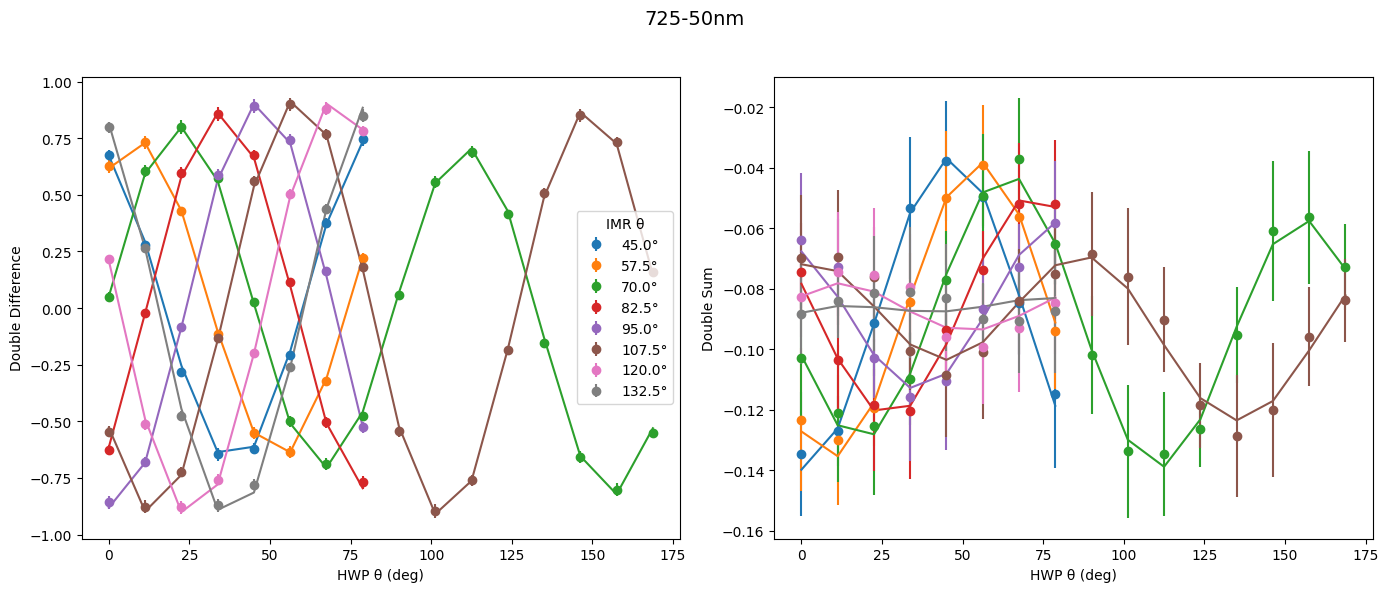

After p0: {'dichroic': {'phi': -0.03148491756266718, 'epsilon': 0.3752145901967978, 'theta': -37.86708590639323}, 'flc': {'phi': 3.2292009004958757, 'delta_theta': 4.99999999923195}, 'optics': {'phi': 0.3500607254665466, 'epsilon': 0.002862303502698703, 'theta': -48.40078049216592}, 'image_rotator': {'phi': 2.759684754702262}, 'hwp': {'phi': 2.998058995280476, 'delta_theta': 1.8731030867277596}, 'lp': {'theta': 4.9999993268478695}}
Before p0: {'dichroic': {'phi': -0.03148491756266718, 'epsilon': 0.3752145901967978, 'theta': -37.86708590639323}, 'flc': {'phi': 3.2292009004958757, 'delta_theta': 4.99999999923195}, 'optics': {'phi': 0.3500607254665466, 'epsilon': 0.002862303502698703, 'theta': -48.40078049216592}, 'image_rotator': {'phi': 2.759684754702262}, 'hwp': {'phi': 2.998058995280476, 'delta_theta': 1.8731030867277596}, 'lp': {'theta': 4.9999993268478695}}
Iteration #: 18
logl_value: 20.338076147887264
Best Fit Parameters: [-3.14821058e-02  3.75213737e-01 -3.78670710e+01  3.2292044

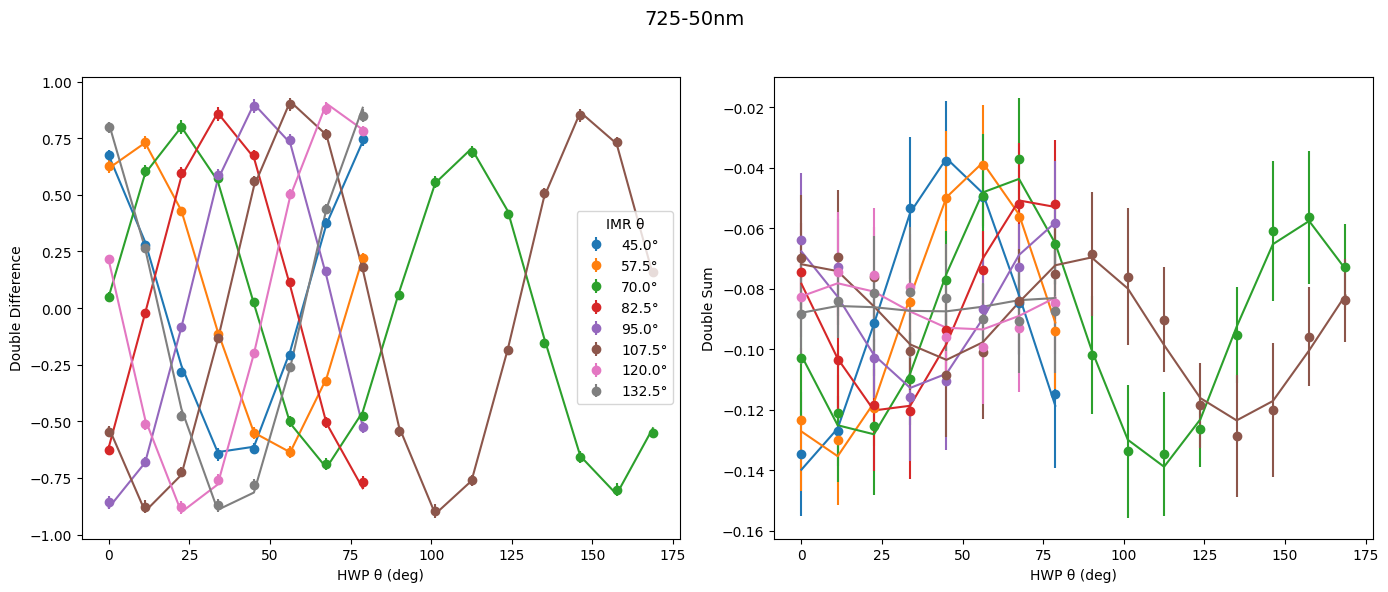

After p0: {'dichroic': {'phi': -0.03148210577277763, 'epsilon': 0.37521373690563775, 'theta': -37.86707102595322}, 'flc': {'phi': 3.229204490357363, 'delta_theta': 5.0}, 'optics': {'phi': 0.35006218600835426, 'epsilon': 0.002862533746759646, 'theta': -48.40068301996495}, 'image_rotator': {'phi': 2.7596842545281834}, 'hwp': {'phi': 2.998058829630227, 'delta_theta': 1.8731059746883454}, 'lp': {'theta': 4.9999995238073165}}
Before p0: {'dichroic': {'phi': -0.03148210577277763, 'epsilon': 0.37521373690563775, 'theta': -37.86707102595322}, 'flc': {'phi': 3.229204490357363, 'delta_theta': 5.0}, 'optics': {'phi': 0.35006218600835426, 'epsilon': 0.002862533746759646, 'theta': -48.40068301996495}, 'image_rotator': {'phi': 2.7596842545281834}, 'hwp': {'phi': 2.998058829630227, 'delta_theta': 1.8731059746883454}, 'lp': {'theta': 4.9999995238073165}}
Iteration #: 19
logl_value: 20.338076135067187
Best Fit Parameters: [-3.14839141e-02  3.75215112e-01 -3.78671076e+01  3.22920188e+00
  5.00000000e+00

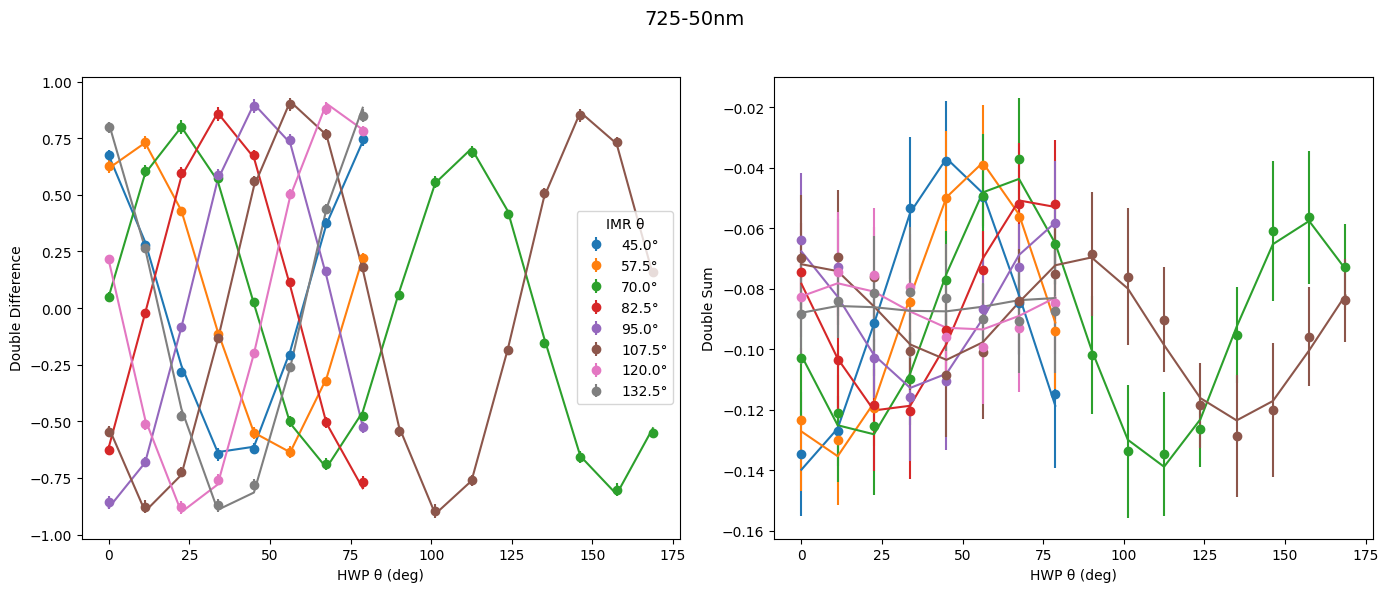

After p0: {'dichroic': {'phi': -0.03148391413378759, 'epsilon': 0.3752151122651738, 'theta': -37.86710760566436}, 'flc': {'phi': 3.2292018836768963, 'delta_theta': 4.999999999792882}, 'optics': {'phi': 0.3500599901328948, 'epsilon': 0.002862244407300569, 'theta': -48.400602717629454}, 'image_rotator': {'phi': 2.7596844806450935}, 'hwp': {'phi': 2.998059025581303, 'delta_theta': 1.8731069733150405}, 'lp': {'theta': 4.999999771097821}}
Before p0: {'dichroic': {'phi': -0.03148391413378759, 'epsilon': 0.3752151122651738, 'theta': -37.86710760566436}, 'flc': {'phi': 3.2292018836768963, 'delta_theta': 4.999999999792882}, 'optics': {'phi': 0.3500599901328948, 'epsilon': 0.002862244407300569, 'theta': -48.400602717629454}, 'image_rotator': {'phi': 2.7596844806450935}, 'hwp': {'phi': 2.998059025581303, 'delta_theta': 1.8731069733150405}, 'lp': {'theta': 4.999999771097821}}
Iteration #: 20
logl_value: 20.338076128143072
Best Fit Parameters: [-3.14828965e-02  3.75214501e-01 -3.78670865e+01  3.229

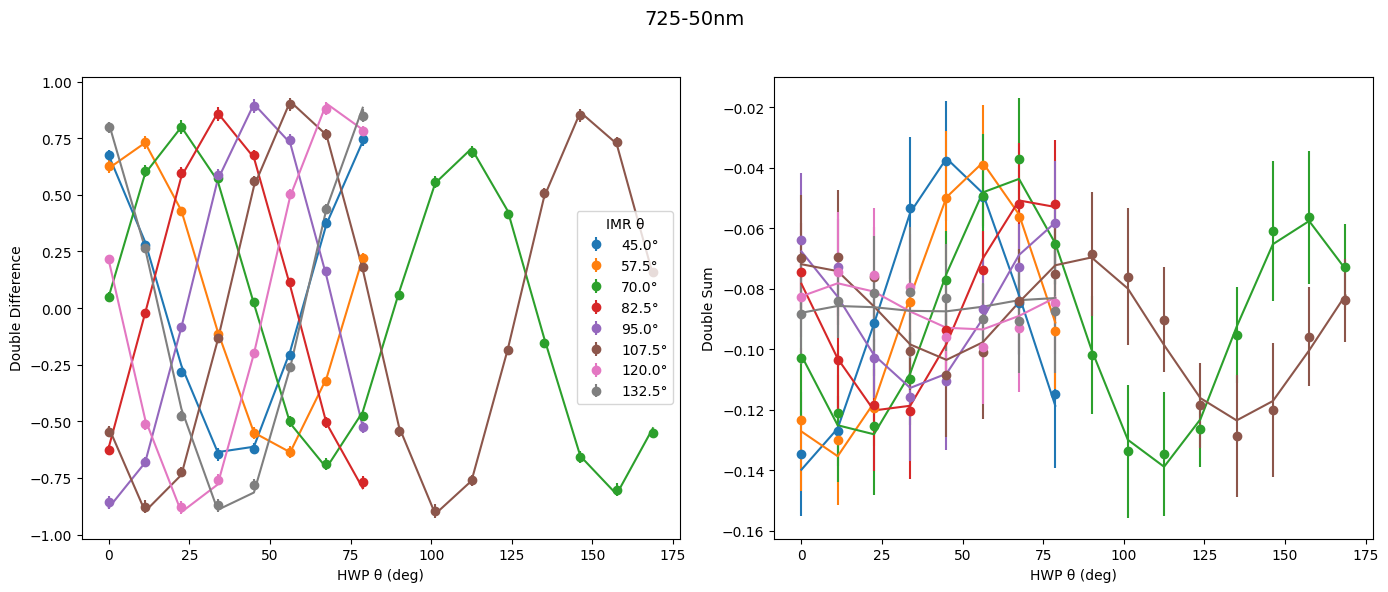

After p0: {'dichroic': {'phi': -0.031482896492994045, 'epsilon': 0.3752145010646989, 'theta': -37.86708654382863}, 'flc': {'phi': 3.229204126257944, 'delta_theta': 4.999999998620282}, 'optics': {'phi': 0.3500614630348799, 'epsilon': 0.0028624460860923904, 'theta': -48.40058448199499}, 'image_rotator': {'phi': 2.7596850695057062}, 'hwp': {'phi': 2.9980591503473653, 'delta_theta': 1.8731073351383842}, 'lp': {'theta': 4.999999910818158}}
Before p0: {'dichroic': {'phi': -0.031482896492994045, 'epsilon': 0.3752145010646989, 'theta': -37.86708654382863}, 'flc': {'phi': 3.229204126257944, 'delta_theta': 4.999999998620282}, 'optics': {'phi': 0.3500614630348799, 'epsilon': 0.0028624460860923904, 'theta': -48.40058448199499}, 'image_rotator': {'phi': 2.7596850695057062}, 'hwp': {'phi': 2.9980591503473653, 'delta_theta': 1.8731073351383842}, 'lp': {'theta': 4.999999910818158}}
Iteration #: 21
logl_value: 20.338076121786166
Best Fit Parameters: [-3.14819168e-02  3.75214592e-01 -3.78670903e+01  3.2

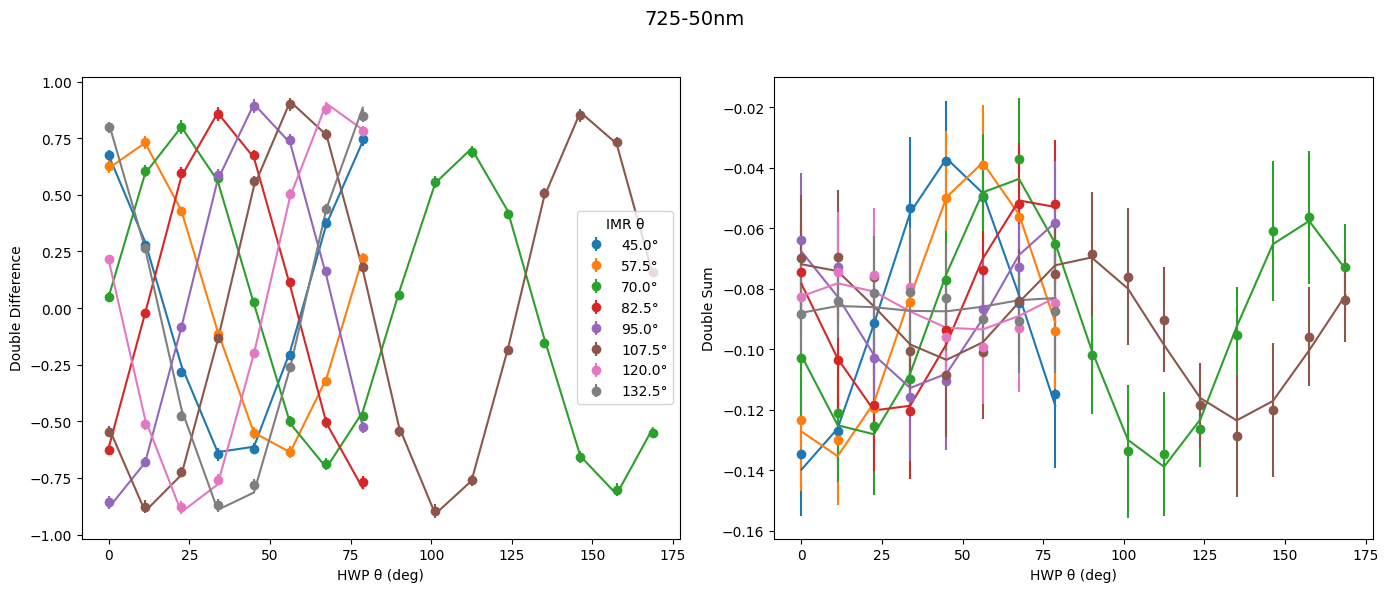

After p0: {'dichroic': {'phi': -0.0314819168393862, 'epsilon': 0.375214591622026, 'theta': -37.86709032794474}, 'flc': {'phi': 3.229205759656426, 'delta_theta': 4.9999999997504885}, 'optics': {'phi': 0.3500619624227417, 'epsilon': 0.0028623469769647, 'theta': -48.400567534857046}, 'image_rotator': {'phi': 2.7596852675586145}, 'hwp': {'phi': 2.9980588095949106, 'delta_theta': 1.8731071974285654}, 'lp': {'theta': 4.999999989826851}}
Before p0: {'dichroic': {'phi': -0.0314819168393862, 'epsilon': 0.375214591622026, 'theta': -37.86709032794474}, 'flc': {'phi': 3.229205759656426, 'delta_theta': 4.9999999997504885}, 'optics': {'phi': 0.3500619624227417, 'epsilon': 0.0028623469769647, 'theta': -48.400567534857046}, 'image_rotator': {'phi': 2.7596852675586145}, 'hwp': {'phi': 2.9980588095949106, 'delta_theta': 1.8731071974285654}, 'lp': {'theta': 4.999999989826851}}
Iteration #: 22
logl_value: 20.338076121786166
Best Fit Parameters: [-3.14819168e-02  3.75214592e-01 -3.78670903e+01  3.22920576e

In [7]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds = [ 
    (-2 * np.pi, 2 * np.pi), # dichroic_retardance
    (0, 1), # dichroic_diattenuation
    (-90, 90), # dichroic_rotation_angle 
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # delta_FLC
    (-5, 5),  # rot_FLC
    (-2 * np.pi, 2 * np.pi),  # delta_opts
    (0, 1),  # epsilon_opts
    (-90, 90),  # rot_opts
    (delta_derot - abs(delta_derot) * 0.1, delta_derot + abs(delta_derot) * 0.1),  # delta_derot
    (delta_HWP - abs(delta_HWP) * 0.1, delta_HWP + abs(delta_HWP) * 0.1),  # delta_HWP
    (-5, 5),  # offset_HWP
    (-5, 5),  # theta_pol
]
# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values_EM_gain_1.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

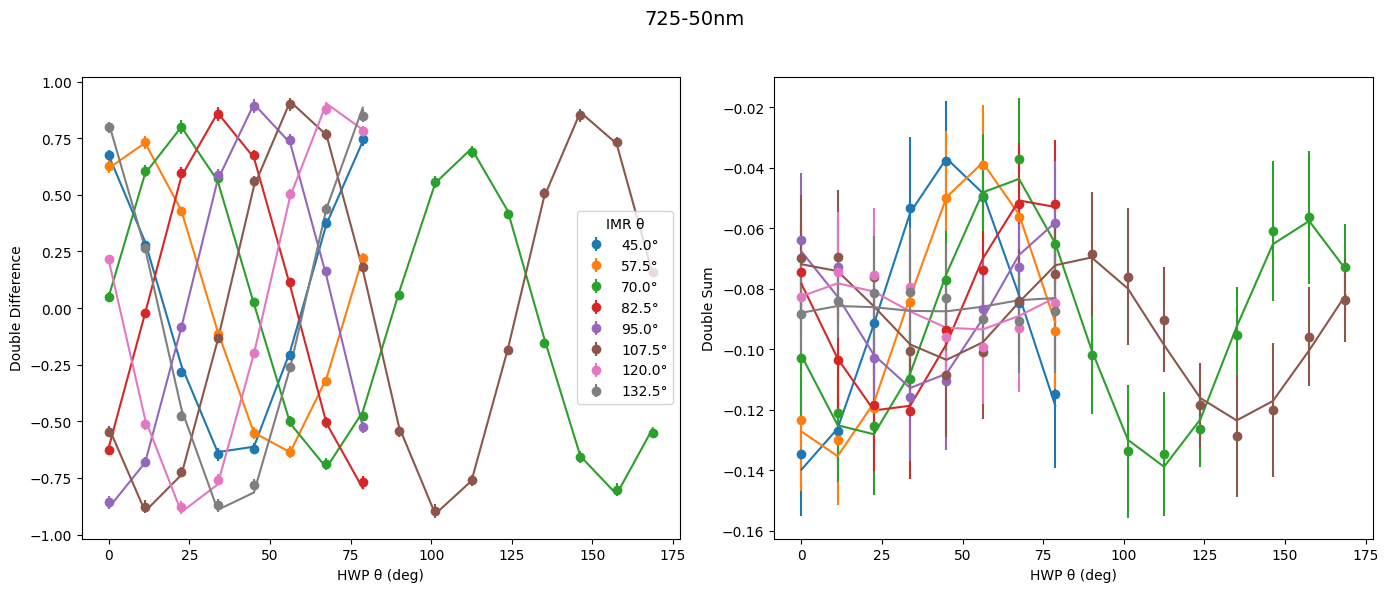

In [8]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)